# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import os

# Mengatur gaya visualisasi data agar scannable
sns.set_theme(style="whitegrid")
print("Library eksperimen berhasil di-import!")

Library eksperimen berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Menentukan lokasi berkas diabetes.csv di penyimpanan lokal Colab Anda
local_path = "diabetes.csv"

# Nama kolom resmi berdasarkan dokumentasi UCI Machine Learning
column_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

# Validasi prapemrosesan untuk memastikan file sudah siap di panel kiri
if os.path.exists(local_path):
    # Menggunakan skiprows=1 untuk melewati baris header bawaan file CSV Anda
    df = pd.read_csv(local_path, names=column_names, skiprows=1)
    print(f"Berhasil memuat dataset dari penyimpanan lokal: '{local_path}'")
    print(f"Ukuran Dataset: {df.shape[0]} baris dan {df.shape[1]} kolom.")
    display(df.head())
else:
    raise FileNotFoundError(
        f"Berkas '{local_path}' tidak ditemukan di penyimpanan lokal Colab. "
        "Silakan unggah berkas 'diabetes.csv' terlebih dahulu melalui panel folder di kiri."
    )

Berhasil memuat dataset dari penyimpanan lokal: 'diabetes.csv'
Ukuran Dataset: 768 baris dan 9 kolom.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== Struktur Data Mentah ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== Ringkasan Statistik ===
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531

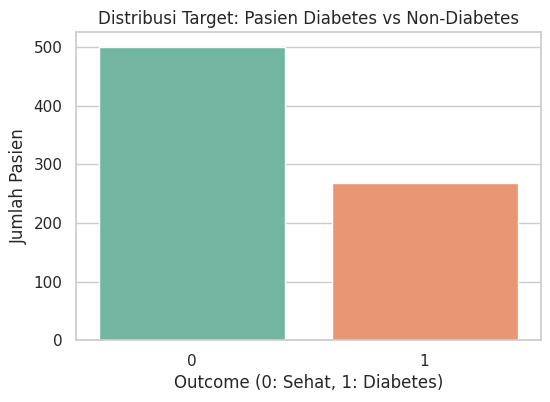

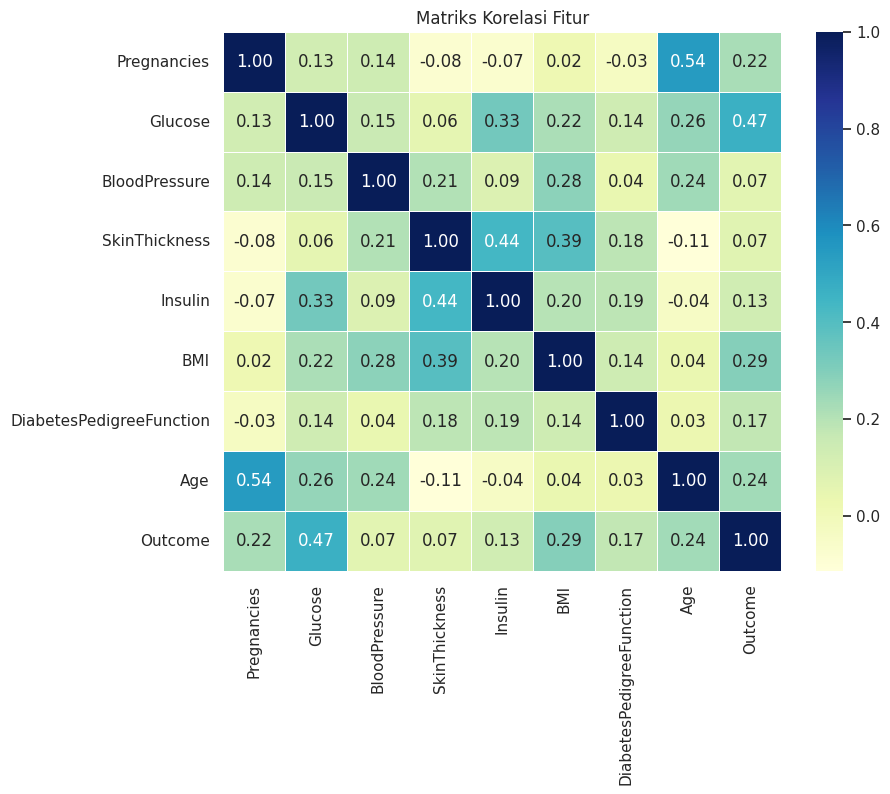

In [3]:
# 1. Cek tipe data dan nilai non-null awal
print("=== Struktur Data Mentah ===")
df.info()

# 2. Cek statistik deskriptif untuk melihat kejanggalan nilai minimum 0
print("\n=== Ringkasan Statistik ===")
print(df.describe())

# 3. Visualisasi distribusi kelas target (Outcome)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', hue='Outcome', palette='Set2', legend=False)
plt.title('Distribusi Target: Pasien Diabetes vs Non-Diabetes')
plt.xlabel('Outcome (0: Sehat, 1: Diabetes)')
plt.ylabel('Jumlah Pasien')
plt.show()

# 4. Korelasi matriks antar fitur medis pasien
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Fitur')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 1. Menangani Nilai Tidak Logis (Invalid Zeros)
# Secara medis, fitur berikut tidak boleh bernilai 0. Kita ubah ke NaN agar bisa di-impute.
invalid_zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[invalid_zero_features] = df[invalid_zero_features].replace(0, np.nan)

print("=== Jumlah Missing Values Setelah Konversi Nilai 0 ===")
print(df.isnull().sum())

# 2. Imputasi Missing Values menggunakan Median (Kokoh terhadap pencilan/outlier)
imputer = SimpleImputer(strategy='median')
df[invalid_zero_features] = imputer.fit_transform(df[invalid_zero_features])

# 3. Membersihkan Baris Duplikat (jika ada)
duplicates = df.duplicated().sum()
print(f"\nMenghapus {duplicates} baris duplikat yang terdeteksi.")
df = df.drop_duplicates()

# 4. Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 5. Standarisasi Fitur Numerik menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Mengonversi kembali hasil transformasi ke bentuk DataFrame siap pakai
df_clean = pd.DataFrame(X_scaled, columns=X.columns)
df_clean['Outcome'] = y.values

# 7. MENYIMPAN HASIL PREPROCESSING SEBAGAI DATASET BARU
output_filename = "diabetes_clean.csv"
df_clean.to_csv(output_filename, index=False)

print("\n=== Selesai! File Output Berhasil Diekspor ===")
print(f"Data bersih disimpan dengan nama: '{output_filename}'")
print(f"Ukuran data siap latih: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom.")
display(df_clean.head())

=== Jumlah Missing Values Setelah Konversi Nilai 0 ===
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Menghapus 0 baris duplikat yang terdeteksi.

=== Selesai! File Output Berhasil Diekspor ===
Data bersih disimpan dengan nama: 'diabetes_clean.csv'
Ukuran data siap latih: 768 baris, 9 kolom.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995,1
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672,0
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584,1
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549,0
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496,1
